# DA2-RL-03 — Đánh giá DQN Bot & So sánh với Buy & Hold

Notebook này:
1. Load `test_df.parquet` (20% cuối, chronological, được tạo ở DA2-RL-02) và
   model weights `dqn_weights.h5`.
2. Chạy DQN bot trên tập test (epsilon = 0, hành động hoàn toàn greedy).
3. Tính Buy & Hold benchmark (mua đều 15 coin từ đầu, không rebalance).
4. Vẽ biểu đồ portfolio value, tính Total Return / Sharpe Ratio / Max Drawdown.


In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../DA2-RL-01"))
sys.path.append(os.path.abspath("../DA2-RL-02"))
from environment import CryptoTradingEnv, build_discrete_action_set
from tensorflow import keras
from tensorflow.keras import layers


## 1. Load test set + model

In [2]:
test_df = pd.read_parquet("../DA2-RL-02/test_df.parquet")
print(f"Test set: {len(test_df)} dòng, {test_df.shape[1]} coin")

env = CryptoTradingEnv(test_df, window_size=10, transaction_cost=0.001, eta=0.01)
action_templates = build_discrete_action_set(env.n_assets, concentration=0.8)
action_size = len(action_templates)


Test set: 98 dòng, 14 coin


In [3]:
# Rebuild kiến trúc model giống DA2-RL-02 rồi load lại weights đã train
def build_model(state_size, action_size, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(state_size,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(action_size, activation="linear"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return model

model = build_model(env.state_size, action_size)
model.load_weights("../DA2-RL-02/dqn_weights.weights.h5")
print("Đã load dqn_weights.weights.h5")


Đã load dqn_weights.weights.h5


/opt/conda/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 2. Chạy DQN Bot trên tập test (greedy, epsilon = 0)

In [4]:
state = env.reset(start_index=None)  # bắt đầu từ đầu test set
bot_portfolio = [env.portfolio_value]
bot_weights_history = [env.weights.copy()]

done = False
while not done:
    q_values = model.predict(state[np.newaxis, :], verbose=0)
    action_idx = int(np.argmax(q_values[0]))
    weights = action_templates[action_idx]
    state, reward, done, info = env.step(weights)
    bot_portfolio.append(env.portfolio_value)
    bot_weights_history.append(env.weights.copy())

bot_portfolio = np.array(bot_portfolio)
print(f"Số bước: {len(bot_portfolio)} | Portfolio value cuối: {bot_portfolio[-1]:.4f}")


Số bước: 87 | Portfolio value cuối: 0.6947


## 3. Buy & Hold benchmark

Mua đều 15 coin (equal-weight) từ bước đầu tiên, giữ nguyên không rebalance
đến cuối — không tính phí giao dịch lại (chỉ phí mua ban đầu, bỏ qua vì cố
định cho cả 2 chiến lược).

In [5]:
returns_test = env.returns_values  # log-return từng coin trong đoạn test, từ window_size trở đi
start_t = env.window_size
bh_returns = returns_test[start_t:start_t + len(bot_portfolio) - 1]

bh_weights = np.ones(env.n_assets) / env.n_assets
bh_portfolio_returns = bh_returns @ bh_weights      # log-return danh mục mỗi bước
buyhold_portfolio = np.concatenate([[1.0], np.exp(np.cumsum(bh_portfolio_returns))])

print(f"Buy & Hold portfolio value cuối: {buyhold_portfolio[-1]:.4f}")


Buy & Hold portfolio value cuối: 0.6995


## 4. Biểu đồ so sánh

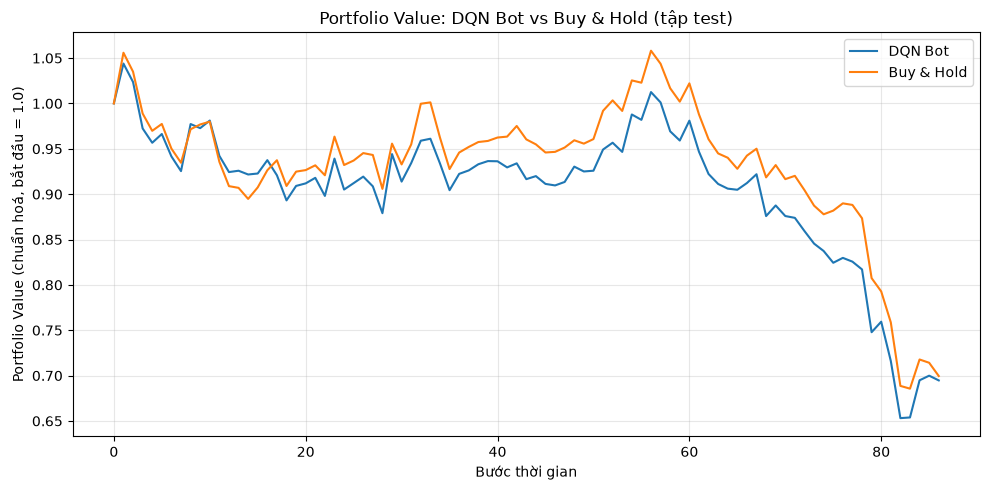

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(bot_portfolio, label="DQN Bot")
plt.plot(buyhold_portfolio, label="Buy & Hold")
plt.title("Portfolio Value: DQN Bot vs Buy & Hold (tập test)")
plt.xlabel("Bước thời gian")
plt.ylabel("Portfolio Value (chuẩn hoá, bắt đầu = 1.0)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("portfolio_value.png", dpi=150)
plt.show()


## 5. Bảng kết quả: Total Return, Sharpe Ratio, Max Drawdown

In [7]:
def compute_metrics(portfolio_values, periods_per_year=365):
    portfolio_values = np.asarray(portfolio_values)
    step_returns = np.diff(np.log(portfolio_values))   # log-return mỗi bước

    total_return = portfolio_values[-1] / portfolio_values[0] - 1

    mean_r = step_returns.mean()
    std_r = step_returns.std() + 1e-8
    sharpe = (mean_r / std_r) * np.sqrt(periods_per_year)   # annualized Sharpe

    running_max = np.maximum.accumulate(portfolio_values)
    drawdown = (portfolio_values - running_max) / running_max
    max_drawdown = drawdown.min()

    return {
        "Total Return": f"{total_return:.2%}",
        "Sharpe Ratio (annualized)": f"{sharpe:.3f}",
        "Max Drawdown": f"{max_drawdown:.2%}",
    }

results = pd.DataFrame({
    "DQN Bot": compute_metrics(bot_portfolio),
    "Buy & Hold": compute_metrics(buyhold_portfolio),
})
results


,DQN Bot,Buy & Hold
Total Return,-30.53%,-30.05%
Sharpe Ratio (annualized),-2.990,-3.048
Max Drawdown,-37.44%,-35.21%


In [8]:
results.to_csv("metrics_comparison.csv")
print(results)


                           DQN Bot Buy & Hold
Total Return               -30.53%    -30.05%
Sharpe Ratio (annualized)   -2.990     -3.048
Max Drawdown               -37.44%    -35.21%
